# Хинчагов Руслан Артурович - 3 Группа ДПО
Инженерия ИИ - Домашнее задание 2 

In [200]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

In [201]:
df = pd.read_csv('./data/S02-hw-dataset.csv') #выгружаем dataset в dataFrame 
print(df.shape)

df.head() #Выводим первые 5 строк датасета с помощью head()

(41, 5)


,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [202]:
df.info() #выводим инфу название колонок, их количество, типы данных и так далее


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [203]:
print(df.describe()) #выводим базовую описательную статистику датасета

         user_id         age  purchases      revenue
count  41.000000   39.000000  41.000000    41.000000
mean   20.243902   36.512821   4.829268   820.048780
std    11.659289   18.304259   2.710189   613.127269
min     1.000000    5.000000  -1.000000     0.000000
25%    10.000000   24.000000   3.000000   432.000000
50%    20.000000   33.000000   5.000000   693.000000
75%    30.000000   45.500000   7.000000  1115.000000
max    40.000000  120.000000  11.000000  2475.000000


In [204]:
df.isna().mean() # ищем столбцы где есть пропуски 

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

In [205]:
dup = df.duplicated(keep=False) # находим дубликаты
print(df[dup]) # выводим строки у которых показало True
ids = df[dup].index.tolist() # получаем их индексы 
ids 

    user_id   age country  purchases  revenue
9        10  24.0      RU          7      511
40       10  24.0      RU          7      511


[9, 40]

In [206]:
bad_ages = df[df['age'].isna() | (df['age'] > 100) | ((df['age'] < 14) & (df['country'] == 'RU'))] # получаем строки без возрастов или нелогичным возрастом передаем их в bad_age
print('Bad ages rows:\n', bad_ages)

bad_purchases = df[df['purchases'] < 0] # получаем
print('Bad purchases rows:\n', bad_purchases)

bad_revenue = df[(df['revenue'] <= 0) & (df['purchases'] > 0) | (df['revenue'] < 0)]
# передаем если доход равен нулю но есть покупки, или доход отрицательный
print('Bad revenues rows:\n',bad_revenue)

Bad ages rows:
     user_id    age country  purchases  revenue
4         5    NaN      DE          6     1296
5         6  120.0      FR         -1      785
12       13    NaN      US          9      630
20       21    5.0      RU          8     1488
Bad purchases rows:
    user_id    age country  purchases  revenue
5        6  120.0      FR         -1      785
Bad revenues rows:
     user_id   age country  purchases  revenue
10       11  24.0      US          4        0


В ходе валидации датасета, были обнаружены нелогичные данные в колонке возраста: 

Две строки содержали NaN(Not a Number), одна содержала возраст больше ста лет, а еще одна возраст меньше 14, при том условии что пользователь находиться в России, получать доход `(revenue)` он не имеет возможности, а совершать покупки с 0 доходом он не смог бы. 

В столбце `purchases` было найдено отрицательное значение 

В столбце `revenue` был найден нулевой доход с ненулевыми покупками

In [207]:
follow_RU = df[df['country'].isin(['RU',])] #ищем записи по country == RU 
print(follow_RU)

print("Count of rows:",follow_RU['country'].count()) #количество таких записей 

    user_id   age country  purchases  revenue
1         2  24.0      RU          5     1115
3         4  31.0      RU          6      654
6         7  46.0      RU          0        0
9        10  24.0      RU          7      511
17       18  24.0      RU          0        0
18       19  47.0      RU          3      432
19       20  31.0      RU          2      442
20       21   5.0      RU          8     1488
24       25  21.0      RU          5      650
26       27  54.0      RU          6     1302
31       32  26.0      RU          6     1080
39       40  34.0      RU          7     2086
40       10  24.0      RU          7      511
Count of rows: 13


In [208]:
print(df.value_counts(df['age'] > 30)[True]) #Выведем количество людей больше 30 лет

print(df.country.value_counts()) #Выведем количество встречающихся категорий в странах

df['revenue_group'] = pd.qcut(df['revenue'], q=4, labels=['low','med-low','med-high', 'high'])
#Разбиваем доход на квантили и выписываем их в новый столбец
print(df.head())

24
country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64
   user_id   age country  purchases  revenue revenue_group
0        1  25.0      FR          7      749      med-high
1        2  24.0      RU          5     1115      med-high
2        3  52.0      FR          7      399           low
3        4  31.0      RU          6      654       med-low
4        5   NaN      DE          6     1296          high


In [209]:
group_by_revenue = df.groupby('revenue_group') 

group_by_revenue.revenue.agg(['mean','sum','count']) 
#делаем группировку по статусу заработка и выводим агрегаты 


/var/folders/r6/yd7rf7xx7yvfbgk45dzmbs1h0000gn/T/ipykernel_54903/2827693524.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_revenue = df.groupby('revenue_group')


,mean,sum,count
revenue_group,,,
low,202.909091,2232,11
med-low,553.800000,5538,10
med-high,898.500000,8985,10
high,1686.700000,16867,10


In [210]:
df['age_group'] = pd.cut(df['age'], bins=[14,40,70,100], labels=['young','middle','old'])
print(df.head())
# разбиваем на возрастные группы начиная с 14 лет, используя bins, и выписываем их в новую колонку

group_by_old = df.groupby('age_group')
group_by_old.age.agg(['mean', 'count'])

   user_id   age country  purchases  revenue revenue_group age_group
0        1  25.0      FR          7      749      med-high     young
1        2  24.0      RU          5     1115      med-high     young
2        3  52.0      FR          7      399           low    middle
3        4  31.0      RU          6      654       med-low     young
4        5   NaN      DE          6     1296          high       NaN


/var/folders/r6/yd7rf7xx7yvfbgk45dzmbs1h0000gn/T/ipykernel_54903/817035294.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_old = df.groupby('age_group')


,mean,count
age_group,,
young,28.32,25
middle,49.25,12
old,NaN,0


# Какие категории доминируют? 
В категориях стран `countries` больше всего доминируют Россия и Франция, 13 и 12 записей 

# Как отличаются категории по средним значениям? 
В категориях заработка `revenue` записей почти одинаковое кол-во, которое равно 10, но средние значения растут почти в 2 раза с каждой следующей категорией 

# Есть ли неожиданные эффекты? 
Да, в группах возраста, у группы `old`, не было найденно записей, а в среднее количество попало значение NaN `Not a Number`, хотя при ненахождении числа, возрастная группа стояла NaN


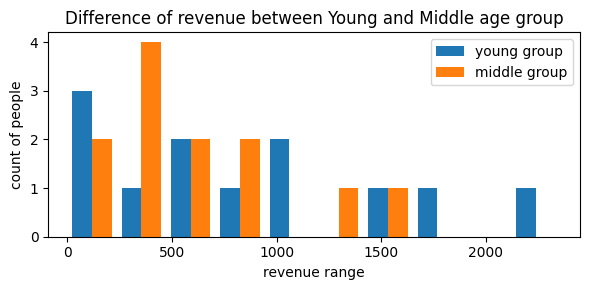

In [233]:
## Создадим гистограмму 

fig, ax = plt.subplots(figsize=(6,3)) 

middle = df[df['age_group']=='middle']['revenue'] 
young = df[df['age_group']=='young']['revenue']
young = young[:middle.size] #ограничиваем набор данных по количеству людей

data = np.column_stack((young,middle)) #создаем набор данных о зароботке людей из двух возрастных групп

ax.hist( 
    data, bins=10, #установил автоматические bins на 10 равных отрезков
    label=('young group', 'middle group')
) 
ax.set_xlabel('revenue range')
ax.set_ylabel('count of people')
ax.legend(loc='upper right')
ax.set_title('Difference of revenue between Young and Middle age group')
plt.tight_layout()
plt.show()
fig.savefig('./figures/histogram_fig')

#По анализу видно что большая част датасета, а именно 4 человека 
# среднего возраста, имеют доход четь меньше 500, доход больше 2000 есть только у 
# одного человека молодого возраста 


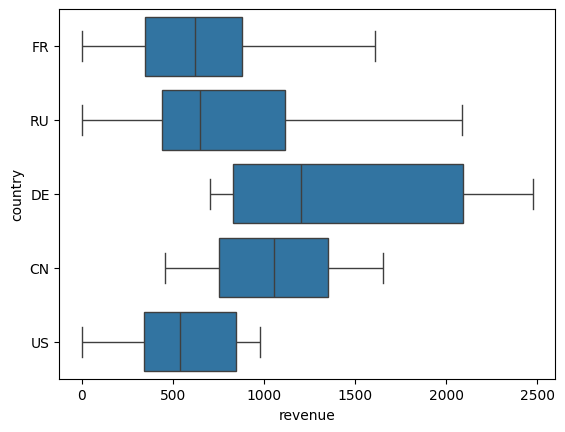

In [239]:
import seaborn as sns 
top_countries = df.country.value_counts().sort_values(ascending=False).head(5).index.values
sns_plot = sns.boxplot(y='country', x='revenue', data=df[df.country.isin(top_countries)], orient='h')
#сделали график boxplot, для стран и их статистики revenue 

sns_plot.figure.savefig('./figures/boxplot_fig')

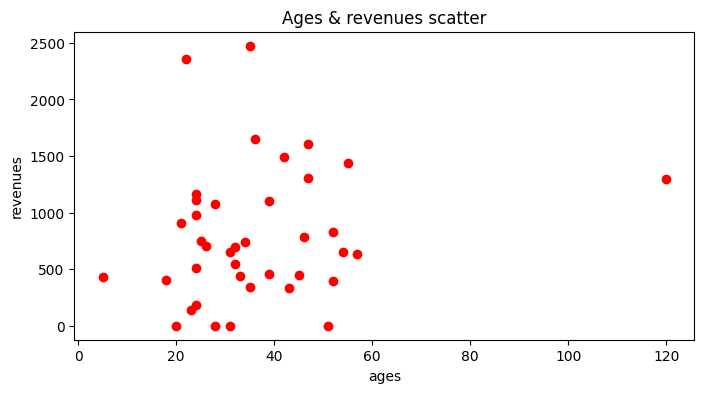

In [256]:
fig_sctr, ax_sctr = plt.subplots(figsize=(8,4))


n = min(len(df['age'].dropna()), len(df['revenue']))
x_data = df['age'].dropna().iloc[:n]
ax_sctr.set_xlabel('ages')
ax_sctr.set_ylabel('revenues')
ax_sctr.set_title('Ages & revenues scatter')



ax_sctr.scatter(x=x_data, y=df['revenue'][:n], c='r')
plt.show() 
## на графике сразу видно невалидированное значение возраст 120, а также видно что 
# наибольшая масса расположенна между 20 и 40 годами.
fig_sctr.savefig('./figures/scatter_fig')